In [9]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
from pdb import set_trace
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy.stats import mannwhitneyu
from sklearn.metrics import silhouette_samples
from statannotations.Annotator import Annotator

In [2]:
# File path
label_path = '/home/ec2-user/Jul2025/labels/'
dataset_path = '/home/ec2-user/Jul2025/processed_datasets_unfiltered/'
figure_output_path = '/home/ec2-user/Jul2025/Fig1_FigS1_UMAP/'

# UMAP exploration

In [ ]:
def plot_umap(df, label_df, label_col, n_neighbors=15, min_dist=0.1, metric='correlation',
              figsize=(6, 6), point_size=25,
              save_path=None, dpi=300):
    """
    Parameters:
    - df: pandas DataFrame, features only (shape: n_samples x n_features)
    - label_df: pandas DataFrame, must align with df index and contain label_col
    - label_col: str, column name in label_df to use for coloring
    - n_neighbors: int, UMAP n_neighbors parameter
    - min_dist: float, UMAP min_dist parameter
    - metric: str, UMAP metric
    - figsize: tuple, figure size
    - point_size: int, size of points
    - palette: seaborn palette
    - title: str, optional title
    - save_path: str, path to save image
    - dpi: int, image resolution

    Returns:
    - None
    """
    compartment_colors = {
    'Cytosol': '#fc8d62',      # Your choice
    'Mitochondria': '#e78ac3', # Your choice
    'Nucleus': '#8da0cb',      # Your choice
    'Secretory': '#66c2a5'     # Your choice
    }

    # Find common indices
    common_indices = df.index.intersection(label_df.index)
    # Make df have the same index as label_df
    df = df.loc[common_indices]
    # Make label_df have the same index as df
    label_df = label_df.loc[common_indices]

    # Check if label_df has the same length as df
    if len(label_df) != len(df):
        raise ValueError("label_df must have the same number of rows as df")
    
    labels = label_df[label_col]

    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
    embedding = reducer.fit_transform(df)

    # Combine embedding and labels
    umap_df = pd.DataFrame(embedding, columns=['UMAP1', 'UMAP2'], index=df.index)
    umap_df[label_col] = labels

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.scatterplot(
        data=umap_df,
        x="UMAP1",
        y="UMAP2",
        hue=label_col,
        palette=compartment_colors,
        s=point_size,
        linewidth=0,
        alpha=0.85)

    # Axis labels
    ax.set_xlabel("UMAP Component 1", fontsize=10)
    ax.set_ylabel("UMAP Component 2", fontsize=10)

    # Remove top and right spines
    sns.despine(ax=ax, top=True, right=True)

    # Spine width
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

    # Legend
    plt.legend(title=label_col, loc='best', frameon=False, fontsize=10)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()

In [3]:
# Read in datasets
# Krug breast 
krug_breast_PD = pd.read_csv(Path(dataset_path + 'Krug_PD_processed_unfiltered.csv'), index_col=0)
krug_breast_MD = pd.read_csv(Path(dataset_path + 'Krug_MD_processed_unfiltered.csv'), index_col=0)

# Mertins breast 
mertins_breast_PD = pd.read_csv(Path(dataset_path + 'breast_tumor_PD_processed_unfiltered.csv'), index_col=0)
mertins_breast_MD = pd.read_csv(Path(dataset_path + 'breast_tumor_MD_processed_unfiltered.csv'), index_col=0)

# Lung tumor
lung_tumor_PD = pd.read_csv(Path(dataset_path + 'lung_tumor_PD_processed_unfiltered.csv'), index_col=0)
lung_tumor_MD = pd.read_csv(Path(dataset_path + 'lung_tumor_MD_processed_unfiltered.csv'), index_col=0)

# Lung NAT
lung_nat_PD = pd.read_csv(Path(dataset_path + 'lung_nat_PD_processed_unfiltered.csv'), index_col=0)
lung_nat_MD = pd.read_csv(Path(dataset_path + 'lung_nat_MD_processed_unfiltered.csv'), index_col=0)

# Glioma tumor
glioma_tumor_PD = pd.read_csv(Path(dataset_path + 'brain_tumor_PD_processed_unfiltered.csv'), index_col=0)
glioma_tumor_MD = pd.read_csv(Path(dataset_path + 'brain_tumor_MD_processed_unfiltered.csv'), index_col=0)


# Assemble all these dfs into a dict
datasets = {
    'Krug_Breast_PD': krug_breast_PD,
    'Krug_Breast_MD': krug_breast_MD,
    'Mertins_Breast_PD': mertins_breast_PD,
    'Mertins_Breast_MD': mertins_breast_MD,
    'Lung_Tumor_PD': lung_tumor_PD,
    'Lung_Tumor_MD': lung_tumor_MD,
    'Lung_NAT_PD': lung_nat_PD,
    'Lung_NAT_MD': lung_nat_MD,
    'Glioma_Tumor_PD': glioma_tumor_PD,
    'Glioma_Tumor_MD': glioma_tumor_MD
}

In [6]:
# Read in labels
compartment_labels = pd.read_csv(Path(label_path + 'markers.txt'), sep='\t', index_col=0)

In [ ]:
for name, df in datasets.items():
    plot_umap(df, compartment_labels, 'Localization',
              n_neighbors=100, min_dist=0.1, metric='correlation',
              figsize=(6, 6), point_size=15, save_path=Path(figure_output_path+f'/{name}_umap.pdf'),
              dpi=300)

# Silhouette score

In [11]:
def analyze_and_save_cohesion(datasets_dict, label_df, label_col, 
                             n_neighbors=100, min_dist=0.1, metric='correlation',
                             save_root=None, dpi=300):
    """
    Groups datasets by study, runs UMAP/Silhouette, and saves results in 
    study-specific folders.
    """
    custom_order = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']
    
    # Identify unique studies (e.g., 'Krug_Breast', 'Lung_Tumor')
    # This ignores the _PD/_MD suffix to find the group name
    studies = sorted(set("_".join(k.split("_")[:-1]) for k in datasets_dict.keys()))
    studies = set(studies)

    for study in studies:
        print(f"--- Processing Study: {study} ---")
        all_results = []
        
        # Process only the PD and MD pairs for THIS study
        for suffix in ['PD', 'MD']:
            name = f"{study}_{suffix}"
            if name in datasets_dict:
                df = datasets_dict[name]
                
                # Align data indices with labels
                common_idx = df.index.intersection(label_df.index)
                df_sub = df.loc[common_idx]
                labels_sub = label_df.loc[common_idx, label_col]
                
                # Perform UMAP dimensionality reduction
                reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, 
                                   metric=metric, random_state=42)
                embedding = reducer.fit_transform(df_sub)
                
                # Calculate Silhouette Scores (Nearness metric)
                scores = silhouette_samples(embedding, labels_sub)
                
                res_df = pd.DataFrame({
                    'Score': scores,
                    'Localization': labels_sub.values,
                    'Dataset_Name': name,
                    'Type': 'Proteome' if suffix == 'PD' else 'Transcriptome'
                }, index=common_idx)
                all_results.append(res_df)

        final_scores_df = pd.concat(all_results)

        # Statistical Summary (U-test)
        stats_list = []
        for loc in custom_order:
            p_vals = final_scores_df[(final_scores_df['Localization'] == loc) & (final_scores_df['Type'] == 'Proteome')]['Score']
            t_vals = final_scores_df[(final_scores_df['Localization'] == loc) & (final_scores_df['Type'] == 'Transcriptome')]['Score']
            
            if len(p_vals) > 0 and len(t_vals) > 0:
                u, p = mannwhitneyu(p_vals, t_vals, alternative='two-sided')
                stats_list.append({'Localization': loc, 'p_value': p, 'U_statistic': u})
        
        stats_df = pd.DataFrame(stats_list)

        # Plotting
        plt.figure(figsize=(6, 4))
        ax = sns.violinplot(
            data=final_scores_df, x='Localization', y='Score', hue='Type',
            order=custom_order, split=True, inner="quartile",
            palette={'Proteome': '#4c72b0', 'Transcriptome': '#dd8452'}
        )
        
        # Add significance annotations
        pairs = [((loc, "Proteome"), (loc, "Transcriptome")) for loc in custom_order]
        annotator = Annotator(ax, pairs, data=final_scores_df, x='Localization', y='Score', 
                             hue='Type', order=custom_order)
        annotator.configure(test='Mann-Whitney', text_format='star', loc='outside')
        annotator.apply_and_annotate()

        plt.axhline(0, color='red', linestyle='--', alpha=0.5)
        plt.yticks(np.arange(-1, 1.5, 0.5))
        sns.despine(top=True, right=True)
        plt.title(f"Cohesion Analysis: {study}")
        plt.ylabel("Silhouette score")

        # 5. Save Outputs to {study} folder
        if save_root:
            # Syntax fix: Path / folder / filename
            study_path = Path(save_root) / study
            study_path.mkdir(parents=True, exist_ok=True)
            
            plt.savefig(study_path / f"{study}_violin.pdf", bbox_inches='tight', dpi=dpi)
            final_scores_df.to_csv(study_path / f"{study}_scores.csv")
            stats_df.to_csv(study_path / f"{study}_pvalues.csv")
            
        plt.show()
        plt.close() # Free up memory

--- Processing Study: Glioma_Tumor ---


/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Mitochondria_Proteome vs. Mitochondria_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.179e-52 U_stat=6.245e+04
Cytosol_Proteome vs. Cytosol_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:5.609e-12 U_stat=4.224e+05
Nucleus_Proteome vs. Nucleus_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:8.609e-125 U_stat=2.791e+05
Secretory_Proteome vs. Secretory_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.437e-64 U_stat=1.882e+05


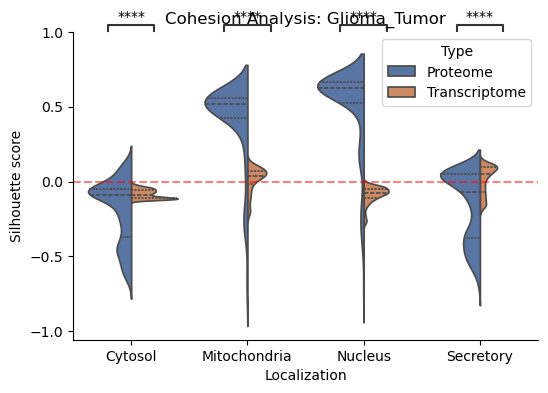

--- Processing Study: Krug_Breast ---


/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Mitochondria_Proteome vs. Mitochondria_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.053e-02 U_stat=3.933e+04
Cytosol_Proteome vs. Cytosol_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.374e-116 U_stat=8.489e+05
Nucleus_Proteome vs. Nucleus_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.580e-125 U_stat=3.464e+05
Secretory_Proteome vs. Secretory_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.417e-37 U_stat=4.069e+05


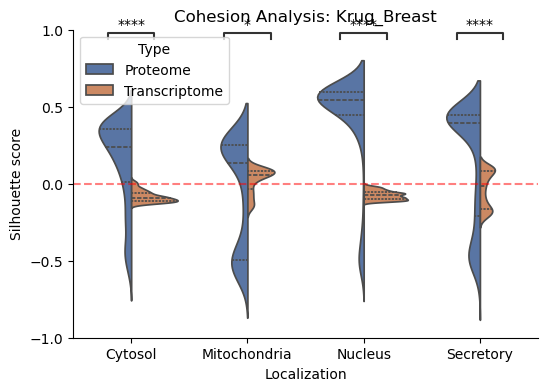

--- Processing Study: Lung_Tumor ---


/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Mitochondria_Proteome vs. Mitochondria_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:5.613e-22 U_stat=5.210e+04
Cytosol_Proteome vs. Cytosol_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.340e-105 U_stat=2.392e+05
Nucleus_Proteome vs. Nucleus_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.058e-93 U_stat=3.252e+05
Secretory_Proteome vs. Secretory_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:2.790e-24 U_stat=4.787e+05


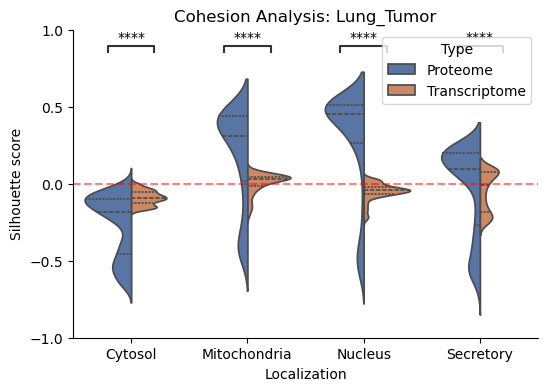

--- Processing Study: Mertins_Breast ---


/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Mitochondria_Proteome vs. Mitochondria_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.916e-04 U_stat=2.375e+04
Cytosol_Proteome vs. Cytosol_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:4.395e-30 U_stat=6.254e+05
Nucleus_Proteome vs. Nucleus_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:4.798e-85 U_stat=2.542e+05
Secretory_Proteome vs. Secretory_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.287e-07 U_stat=1.983e+05


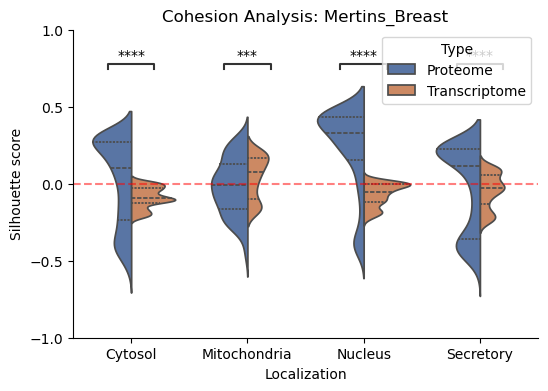

--- Processing Study: Lung_NAT ---


/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/conda/envs/pytorch/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Mitochondria_Proteome vs. Mitochondria_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:1.798e-30 U_stat=5.534e+04
Cytosol_Proteome vs. Cytosol_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:6.866e-01 U_stat=5.312e+05
Nucleus_Proteome vs. Nucleus_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:8.524e-146 U_stat=3.584e+05
Secretory_Proteome vs. Secretory_Transcriptome: Mann-Whitney-Wilcoxon test two-sided, P_val:5.171e-161 U_stat=9.283e+04


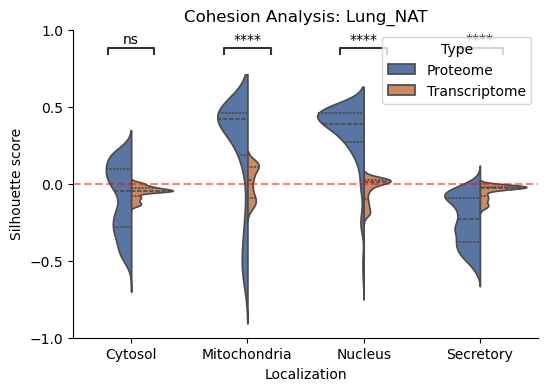

In [12]:
analyze_and_save_cohesion(datasets, compartment_labels, 'Localization',
              n_neighbors=100, min_dist=0.1, metric='correlation',
              save_root=Path(figure_output_path),
              dpi=300)

In [13]:
def aggregate_stats(save_root):
    all_stats = []
    root = Path(save_root)
    
    # Find all p-value files in the subfolders
    for pval_file in root.glob("**/*_pvalues.csv"):
        # The study name is the folder name
        study_name = pval_file.parent.name
        
        df = pd.read_csv(pval_file)
        df['Study'] = study_name
        all_stats.append(df)
    
    if not all_stats:
        print("No stats files found. Check your file names and paths.")
        return None
        
    master_stats = pd.concat(all_stats, ignore_index=True)
    
    # Pivot for a clean comparison table: Studies vs Compartments
    summary_pivot = master_stats.pivot(index='Study', columns='Localization', values='p_value')
    
    return summary_pivot

# Run it
summary_table = aggregate_stats(figure_output_path)
#summary_table.to_csv(figure_output_path / "master_significance_summary.csv")
print(summary_table)

Localization          Cytosol  Mitochondria        Nucleus      Secretory
Study                                                                    
Glioma_Tumor     5.609216e-12  1.179020e-52  8.608828e-125   2.437231e-64
Krug_Breast     2.373867e-116  1.053198e-02  1.580038e-125   2.417006e-37
Lung_NAT         6.865696e-01  1.798021e-30  8.523950e-146  5.171251e-161
Lung_Tumor      2.340135e-105  5.612950e-22   2.058269e-93   2.790263e-24
Mertins_Breast   4.395033e-30  1.915593e-04   4.798324e-85   1.286596e-07
